# Notebook 04: Modelos de Machine Learning

## Objetivo

Entrenar y evaluar modelos que respondan a las 4 preguntas de negocio de Raona:

| Modelo | Pregunta | Técnica |
|--------|----------|--------|
| **Lead Scoring** | A QUIÉN contactar? | Clasificación binaria (LightGBM, XGBoost, LogReg, RF) |
| **Segmentación** | QUÉ tipo de empresa es? | Clustering (K-Means, HDBSCAN) |
| **Recomendación** | CON QUÉ producto? | Análisis de campañas + FIT scores |
| **Canal y Timing** | POR DÓNDE y CUÁNDO? | Análisis estadístico de canales y días |

## Métricas de evaluación (justificadas en NB02)

| Métrica | Rol | Interpretación |
|---------|-----|---------------|
| **PR-AUC** | Principal | Area bajo curva Precisión-Recall (ideal para clases desbalanceadas) |
| **ROC-AUC** | Secundaria | Capacidad general de discriminacion |
| **Precisión@100** | Negocio | De los top 100 leads, cuantos responderian? |
| **Precisión@500** | Negocio | De los top 500 leads, cuantos responderian? |
| **Lift@10%** | Negocio | Cuantas veces mejor que aleatorio en el top 10%? |

## Datos de entrada
- `modeling_dataset_final.parquet` (5,987 filas y 71 columnas) - de NB03

## Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', message='.*overflow.*')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix
)

import lightgbm as lgb
import xgboost as xgb
import optuna
import shap

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

import matplotlib.pyplot as plt
import seaborn as sns

# Rutas
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
WORKING_DATA = os.path.join(PROJECT_ROOT, '..', '_working', 'data')
WORKING_MODELS = os.path.join(PROJECT_ROOT, '..', '_working', 'models')
DELIVERABLE_MODELS = os.path.join(PROJECT_ROOT, 'app', 'models')
os.makedirs(WORKING_MODELS, exist_ok=True)
os.makedirs(DELIVERABLE_MODELS, exist_ok=True)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

optuna.logging.set_verbosity(optuna.logging.WARNING)

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 4.1 Preparación de datos

### Selección de features

Usamos las features numéricas del dataset final. Excluimos:
- Columnas de ID (LinkedIn profile ID, Company URN, Company name)
- Columnas de texto (ai_CONTACT_REPORT, etc.) - ya procesadas en nlp_*
- Categóricas de alta cardinalidad no codificadas (Industry, Geo región) - 
  Industry se podria target-encode pero con 188 valores únicos preferimos 
  dejarlo para una iteracion futura y confiar en las features derivadas
- Variables target

### Train/Test split

80% train / 20% test, **estratificado** por target_replied para mantener 
la proporción de positivos (~14.0%) en ambos conjuntos.

In [2]:
# Cargar datos
df = pd.read_parquet(os.path.join(WORKING_DATA, 'modeling_dataset_final.parquet'))
print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')

# Definir features
FEATURE_COLS = [
    # Raw numericas
    'Years in role', 'Years in company', 'Number of connections',
    'Number of employees', 'Year founded', 'Hiring on LinkedIn',
    'Six months headcount growth', 'Two years headcount growth', 'Yearly headcount growth',
    # Feature engineering
    'fe_seniority_ord', 'fe_type_of_contact_ord',
    'fe_fit_approved', 'fe_fit_data_approved',
    'fe_company_age', 'fe_log_employees', 'fe_company_size_bucket',
    'fe_log_connections', 'fe_headcount_momentum',
    'fe_has_email', 'fe_has_bio', 'fe_microsoft_flag',
    'fe_department_encoded',
    # Tech-product fit (si existen en el dataset)
    # Se añaden dinamicamente abajo
    # Enrichment externo
    'ext_ms_maturity_score', 'ext_has_competitor_tech',
    # NLP
    'nlp_report_length', 'nlp_contact_report_length',
    'nlp_has_momentum', 'nlp_urgency_score',
    'nlp_embedding_01', 'nlp_embedding_02', 'nlp_embedding_03',
    'nlp_topic',
]

# Añadir tech-product fit features si existen
tech_fit_cols = [c for c in df.columns if c.startswith('fe_tech_fit_')]
FEATURE_COLS.extend(tech_fit_cols)
if tech_fit_cols:
    print(f'Tech-product fit features añadidas: {tech_fit_cols}')

TARGET = 'target_replied'

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

print(f'Features: {len(FEATURE_COLS)}')
print(f'Target: {y.sum()} positivos ({y.mean():.1%})')

Dataset: 5,987 filas x 71 columnas
Tech-product fit features añadidas: ['fe_tech_fit_comunica', 'fe_tech_fit_colabora', 'fe_tech_fit_infra', 'fe_tech_fit_ia', 'fe_tech_fit_data', 'fe_tech_fit_workplace', 'fe_tech_fit_maite']
Features: 39
Target: 841 positivos (14.0%)


In [3]:
# Train/Test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]:,} filas ({y_train.sum()} positivos, {y_train.mean():.1%})')
print(f'Test:  {X_test.shape[0]:,} filas ({y_test.sum()} positivos, {y_test.mean():.1%})')

# P1-7: Recompute fe_department_encoded on train set only (avoid leakage)
if 'fe_department_encoded' in FEATURE_COLS:
    SMOOTHING = 20
    train_global_mean = y_train.mean()
    dept_col = 'fe_department_corrected' if 'fe_department_corrected' in df.columns else 'ai_DEPARTMENT'
    
    # Compute department means on train set only
    train_dept = df.loc[X_train.index, dept_col] if dept_col in df.columns else pd.Series('unknown', index=X_train.index)
    train_target = y_train
    dept_stats_train = pd.DataFrame({
        'dept': train_dept,
        'target': train_target
    }).groupby('dept')['target'].agg(['mean', 'count'])
    
    dept_map_train = {}
    for dept, row in dept_stats_train.iterrows():
        smooth = (row['count'] * row['mean'] + SMOOTHING * train_global_mean) / (row['count'] + SMOOTHING)
        dept_map_train[dept] = smooth
    
    # Apply to full dataset (train + test + all)
    if dept_col in df.columns:
        df['fe_department_encoded'] = df[dept_col].map(dept_map_train).fillna(train_global_mean)
    
    # Update X_train and X_test
    X_train = df.loc[X_train.index, FEATURE_COLS]
    X_test = df.loc[X_test.index, FEATURE_COLS]
    X = df[FEATURE_COLS]
    
    print(f'fe_department_encoded recalculado solo con datos de train ({len(X_train)} filas)')


Train: 4,789 filas (673 positivos, 14.1%)
Test:  1,198 filas (168 positivos, 14.0%)
fe_department_encoded recalculado solo con datos de train (4789 filas)


### Preprocessing pipeline

Aplicamos **el mismo preprocesado a todos los modelos** para una competicion justa:
- **Numéricas:** mediana para imputar nulos + StandardScaler
- LightGBM/XGBoost manejan nulos nativamente, pero usamos el pipeline igualmente 
  para compatibilidad con LogReg y RF

Guardamos el preprocessor como `.pkl` para reútilizarlo en la app Streamlit y FastAPI.

In [4]:
# Pipeline de preprocesado
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Fit en train, transform en ambos
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'Train procesado: {X_train_processed.shape}')
print(f'Test procesado: {X_test_processed.shape}')
print(f'Nulos en train procesado: {np.isnan(X_train_processed).sum()}')

# Guardar preprocessor
preprocessor_path = os.path.join(WORKING_MODELS, 'preprocessor.pkl')
with open(preprocessor_path, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f'\nPreprocessor guardado: {preprocessor_path}')

Train procesado: (4789, 39)
Test procesado: (1198, 39)
Nulos en train procesado: 0

Preprocessor guardado: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/models/preprocessor.pkl


---
## 4.2 Modelo 1: Lead Scoring (Clasificación)

### 4.2.1 Funciones auxiliares de evaluación

In [5]:
def evaluate_model(y_true, y_proba, model_name='Model'):
    """Evalua un modelo con todas las metricas relevantes."""
    pr_auc = average_precision_score(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    # Precision@k: de los top k leads por score, cuantos son positivos?
    sorted_idx = np.argsort(-y_proba)  # orden descendente
    y_sorted = np.array(y_true)[sorted_idx]
    
    p_at_100 = y_sorted[:100].mean() if len(y_sorted) >= 100 else np.nan
    p_at_500 = y_sorted[:500].mean() if len(y_sorted) >= 500 else np.nan
    
    # Lift@10%: cuantas veces mejor que aleatorio en el top 10%
    top_10_pct = int(len(y_true) * 0.1)
    top_rate = y_sorted[:top_10_pct].mean()
    base_rate = np.mean(y_true)
    lift_10 = top_rate / base_rate if base_rate > 0 else np.nan
    
    metrics = {
        'Model': model_name,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Precision@100': p_at_100,
        'Precision@500': p_at_500,
        'Lift@10%': lift_10,
    }
    return metrics

print('Funciones de evaluacion definidas')

Funciones de evaluacion definidas


### 4.2.2 Competicion de modelos baseline

Entrenamos 4 modelos con **parámetros por defecto** (excepto ajuste por desbalanceo) 
y comparamos su rendimiento con validación cruzada estratificada de 5 folds.

| Modelo | Tipo | Manejo de desbalanceo |
|--------|------|----------------------|
| Logistic Regression | Lineal, interpretable | class_weight='balanced' |
| Random Forest | Ensemble de árboles | class_weight='balanced' |
| LightGBM | Gradient boosting | scale_pos_weight = ratio neg/pos |
| XGBoost | Gradient boosting | scale_pos_weight = ratio neg/pos |

In [6]:
# Ratio de desbalanceo para scale_pos_weight
neg_pos_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f'Ratio neg/pos: {neg_pos_ratio:.1f}')

# Definir modelos baseline
baseline_models = {
    'LogReg': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, scale_pos_weight=neg_pos_ratio,
        random_state=SEED, verbose=-1, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, scale_pos_weight=neg_pos_ratio,
        random_state=SEED, verbosity=0, n_jobs=-1,
        eval_metric='logloss'
    ),
}

Ratio neg/pos: 6.1


In [7]:
# Entrenar y evaluar cada modelo con CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_results = []

for name, model in baseline_models.items():
    print(f'Entrenando {name}...')
    
    # Cross-validated predictions en train
    cv_probas = cross_val_predict(
        model, X_train_processed, y_train,
        cv=cv, method='predict_proba', n_jobs=-1
    )[:, 1]
    
    cv_metrics = evaluate_model(y_train, cv_probas, f'{name} (CV)')
    
    # Entrenar en todo el train y evaluar en test
    model.fit(X_train_processed, y_train)
    test_probas = model.predict_proba(X_test_processed)[:, 1]
    test_metrics = evaluate_model(y_test, test_probas, f'{name} (Test)')
    
    baseline_results.append(cv_metrics)
    baseline_results.append(test_metrics)
    
    print(f'  CV  PR-AUC: {cv_metrics["PR-AUC"]:.3f} | ROC-AUC: {cv_metrics["ROC-AUC"]:.3f}')
    print(f'  Test PR-AUC: {test_metrics["PR-AUC"]:.3f} | ROC-AUC: {test_metrics["ROC-AUC"]:.3f}')

results_df = pd.DataFrame(baseline_results)
print('\n=== Comparacion de modelos baseline ===')
print(results_df.round(3).to_string(index=False))

Entrenando LogReg...


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/

  CV  PR-AUC: 0.302 | ROC-AUC: 0.677
  Test PR-AUC: 0.270 | ROC-AUC: 0.660
Entrenando RandomForest...


  CV  PR-AUC: 0.324 | ROC-AUC: 0.713
  Test PR-AUC: 0.296 | ROC-AUC: 0.716
Entrenando LightGBM...


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV  PR-AUC: 0.319 | ROC-AUC: 0.705
  Test PR-AUC: 0.301 | ROC-AUC: 0.688
Entrenando XGBoost...


  CV  PR-AUC: 0.316 | ROC-AUC: 0.697
  Test PR-AUC: 0.260 | ROC-AUC: 0.671

=== Comparacion de modelos baseline ===
              Model  PR-AUC  ROC-AUC  Precision@100  Precision@500  Lift@10%
        LogReg (CV)   0.302    0.677           0.60          0.362     2.575
      LogReg (Test)   0.270    0.660           0.32          0.206     1.977
  RandomForest (CV)   0.324    0.713           0.57          0.396     2.843
RandomForest (Test)   0.296    0.716           0.36          0.222     2.637
      LightGBM (CV)   0.319    0.705           0.61          0.384     2.739
    LightGBM (Test)   0.301    0.688           0.37          0.210     2.517
       XGBoost (CV)   0.316    0.697           0.64          0.374     2.709
     XGBoost (Test)   0.260    0.671           0.33          0.204     2.097


In [8]:
# Visualizacion de la competicion
test_results = results_df[results_df['Model'].str.contains('Test')].copy()
test_results['Model'] = test_results['Model'].str.replace(' \(Test\)', '', regex=True)

metrics_to_plot = ['PR-AUC', 'ROC-AUC', 'Precision@100', 'Lift@10%']
fig = make_subplots(rows=1, cols=len(metrics_to_plot),
                    subplot_titles=metrics_to_plot)

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, metric in enumerate(metrics_to_plot):
    fig.add_trace(
        go.Bar(x=test_results['Model'], y=test_results[metric],
               marker_color=colors, showlegend=False,
               text=test_results[metric].round(3), textposition='auto'),
        row=1, col=i+1
    )

fig.update_layout(title='Competicion de modelos baseline (Test set)', height=400)
fig.show()

### 4.2.3 Tuning del mejor modelo con Optuna

Optimizamos los hiperparámetros del **modelo con mejor PR-AUC en test** (LightGBM)
con Optuna (50 trials).

Optuna usa **busqueda bayesiana** (TPE - Tree-structured Parzen Estimator): en lugar de probar
combinaciones aleatorias, aprende de los resultados anteriores para proponer combinaciones
más prometedoras. Es más eficiente que grid search o random search.

In [9]:
# Seleccionar mejor modelo por PR-AUC en test
best_baseline = test_results.nlargest(1, 'PR-AUC')['Model'].tolist()
print(f'Mejor modelo para tuning: {best_baseline}')

Mejor modelo para tuning: ['LightGBM']


In [10]:
# Optuna objective para LightGBM
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': neg_pos_ratio,
        'random_state': SEED,
        'verbose': -1,
        'n_jobs': -1,
    }
    model = lgb.LGBMClassifier(**params)
    probas = cross_val_predict(model, X_train_processed, y_train,
                               cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    return average_precision_score(y_train, probas)

# Optuna objective para XGBoost
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': neg_pos_ratio,
        'random_state': SEED,
        'verbosity': 0,
        'eval_metric': 'logloss',
        'n_jobs': -1,
    }
    model = xgb.XGBClassifier(**params)
    probas = cross_val_predict(model, X_train_processed, y_train,
                               cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    return average_precision_score(y_train, probas)

print('Objectives definidos para Optuna')

Objectives definidos para Optuna


In [11]:
%%time
# Ejecutar Optuna para el mejor modelo
N_TRIALS = 50
tuned_models = {}

objectives = {'LightGBM': lgbm_objective, 'XGBoost': xgb_objective}
model_classes = {'LightGBM': lgb.LGBMClassifier, 'XGBoost': xgb.XGBClassifier}

for model_name in best_baseline:
    if model_name not in objectives:
        print(f'Skipping {model_name} (no objective definido)')
        continue
    
    print(f'\n=== Tuning {model_name} ({N_TRIALS} trials) ===')
    study = optuna.create_study(direction='maximize', 
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objectives[model_name], n_trials=N_TRIALS, show_progress_bar=True)
    
    best_params = study.best_params
    best_params['scale_pos_weight'] = neg_pos_ratio
    best_params['random_state'] = SEED
    if model_name == 'LightGBM':
        best_params['verbose'] = -1
        best_params['n_jobs'] = -1
    elif model_name == 'XGBoost':
        best_params['verbosity'] = 0
        best_params['eval_metric'] = 'logloss'
        best_params['n_jobs'] = -1
    
    print(f'Mejor PR-AUC (CV): {study.best_value:.4f}')
    print(f'Mejores parametros: {best_params}')
    
    # Entrenar modelo final con mejores parametros
    best_model = model_classes[model_name](**best_params)
    best_model.fit(X_train_processed, y_train)
    
    # Evaluar en test
    test_probas = best_model.predict_proba(X_test_processed)[:, 1]
    tuned_metrics = evaluate_model(y_test, test_probas, f'{model_name} (Tuned)')
    print(f'Test PR-AUC: {tuned_metrics["PR-AUC"]:.4f}')
    print(f'Test ROC-AUC: {tuned_metrics["ROC-AUC"]:.4f}')
    
    tuned_models[model_name] = {
        'model': best_model,
        'params': best_params,
        'metrics': tuned_metrics,
        'test_probas': test_probas,
    }


=== Tuning LightGBM (50 trials) ===


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.316782:   0%|          | 0/50 [00:10<?, ?it/s]

Best trial: 0. Best value: 0.316782:   2%|▏         | 1/50 [00:10<08:49, 10.80s/it]

Best trial: 1. Best value: 0.342899:   2%|▏         | 1/50 [00:35<08:49, 10.80s/it]

...

Best trial: 30. Best value: 0.352683:  98%|█████████▊| 49/50 [05:08<00:06,  6.88s/it]

Best trial: 30. Best value: 0.352683: 100%|██████████| 50/50 [05:08<00:00,  6.76s/it]

Best trial: 30. Best value: 0.352683: 100%|██████████| 50/50 [05:08<00:00,  6.16s/it]

Mejor PR-AUC (CV): 0.3527
Mejores parametros: {'n_estimators': 204, 'learning_rate': 0.021451755002801078, 'num_leaves': 118, 'max_depth': 9, 'min_child_samples': 93, 'reg_alpha': 2.0115145364721327e-07, 'reg_lambda': 0.036220980962636574, 'subsample': 0.7772924477809148, 'colsample_bytree': 0.8187795609587191, 'scale_pos_weight': np.float64(6.115898959881129), 'random_state': 42, 'verbose': -1, 'n_jobs': -1}


Test PR-AUC: 0.3028
Test ROC-AUC: 0.6758
CPU times: user 3min 27s, sys: 20min 41s, total: 24min 9s
Wall time: 5min 9s


### 4.2.4 Selección del modelo ganador

In [12]:
# Comparar tuned models
tuned_results = pd.DataFrame([m['metrics'] for m in tuned_models.values()])
print('=== Modelos tuneados (Test set) ===')
print(tuned_results.round(4).to_string(index=False))

# Seleccionar ganador por PR-AUC
winner_name = tuned_results.loc[tuned_results['PR-AUC'].idxmax(), 'Model'].replace(' (Tuned)', '')
winner = tuned_models[winner_name]
print(f'\nModelo ganador: {winner_name}')
print(f'PR-AUC: {winner["metrics"]["PR-AUC"]:.4f}')
print(f'ROC-AUC: {winner["metrics"]["ROC-AUC"]:.4f}')

=== Modelos tuneados (Test set) ===
           Model  PR-AUC  ROC-AUC  Precision@100  Precision@500  Lift@10%
LightGBM (Tuned)  0.3028   0.6758           0.39          0.202    2.5767

Modelo ganador: LightGBM
PR-AUC: 0.3028
ROC-AUC: 0.6758


In [13]:
# Guardar modelo
lead_scorer_path = os.path.join(WORKING_MODELS, 'lead_scorer.pkl')
with open(lead_scorer_path, 'wb') as f:
    pickle.dump(winner['model'], f)
print(f'Lead scorer guardado: {lead_scorer_path}')

# Guardar preprocessor
preprocessor_path = os.path.join(WORKING_MODELS, 'preprocessor.pkl')
with open(preprocessor_path, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f'Preprocessor guardado: {preprocessor_path}')

### 4.2.5 Interpretabilidad con SHAP

SHAP (SHapley Additive exPlanations) nos permite entender **por que** el modelo da una 
puntuación alta o baja a cada contacto. Para cada predicción, SHAP calcula la contribucion 
de cada feature al resultado.

Tipos de análisis:
1. **Summary plot (global):** que features son más importantes en general?
2. **Waterfall (individual):** por que este contacto concreto tiene un score alto/bajo?

In [14]:
# Calcular SHAP values
explainer = shap.TreeExplainer(winner['model'])
shap_values = explainer.shap_values(X_test_processed)

# Para modelos binarios, shap_values puede ser una lista [neg, pos] o un array
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

print(f'SHAP values calculados: {shap_values_pos.shape}')

SHAP values calculados: (1198, 39)


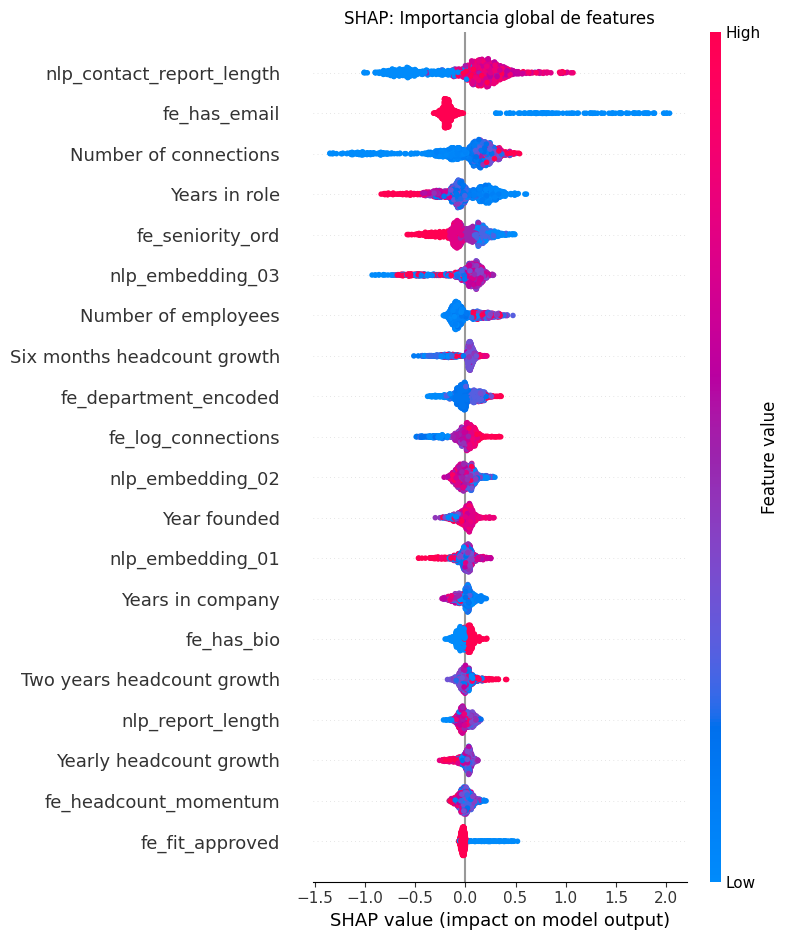

In [15]:
# Summary plot: importancia global de features
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values_pos, X_test_processed,
                  feature_names=FEATURE_COLS, max_display=20, show=False)
plt.title('SHAP: Importancia global de features')
plt.tight_layout()
plt.show()

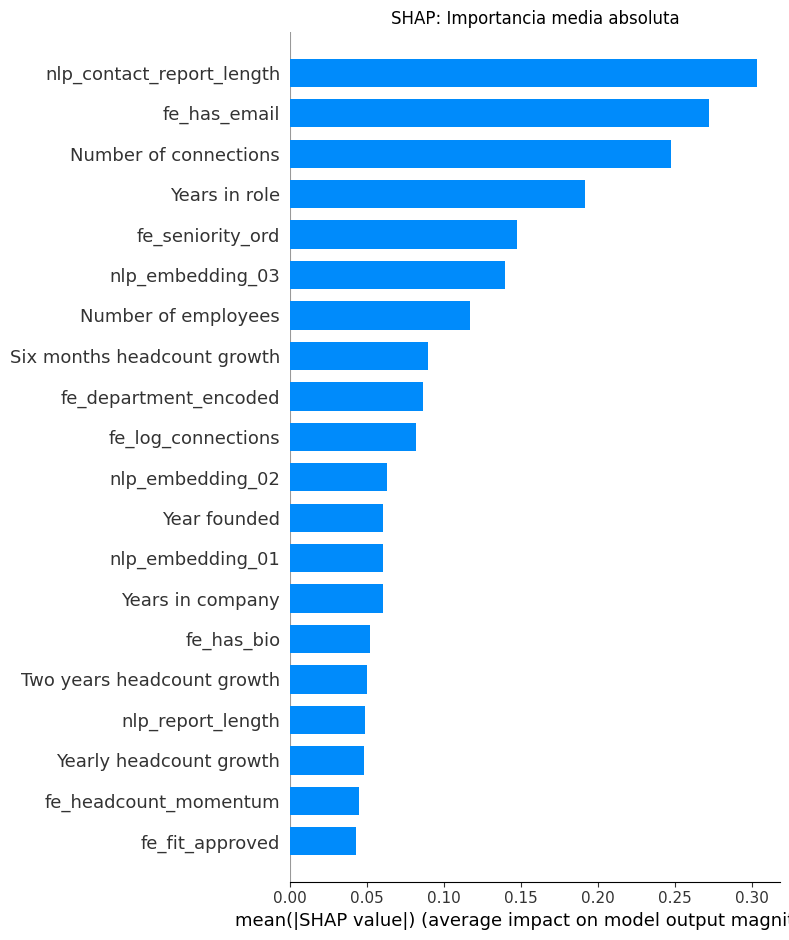

In [16]:
# Bar plot: importancia media absoluta
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_pos, X_test_processed,
                  feature_names=FEATURE_COLS, plot_type='bar', max_display=20, show=False)
plt.title('SHAP: Importancia media absoluta')
plt.tight_layout()
plt.show()

Contacto con score mas alto:
  Score: 0.916
  Real: 1


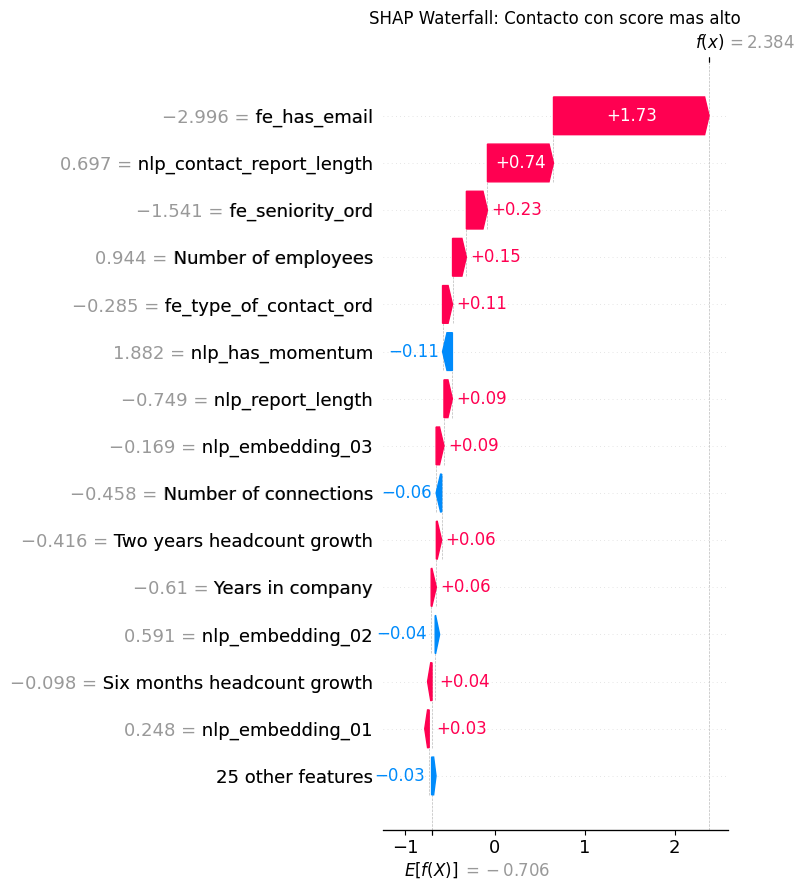

In [17]:
# Waterfall: ejemplo de contacto con score ALTO
test_probas = winner['test_probas']
high_score_idx = np.argsort(-test_probas)[0]  # mayor probabilidad

print(f'Contacto con score mas alto:')
print(f'  Score: {test_probas[high_score_idx]:.3f}')
print(f'  Real: {y_test.iloc[high_score_idx]}')

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_pos[high_score_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) 
                    else explainer.expected_value[1],
        data=X_test_processed[high_score_idx],
        feature_names=FEATURE_COLS,
    ),
    max_display=15, show=False
)
plt.title('SHAP Waterfall: Contacto con score mas alto')
plt.tight_layout()
plt.show()

Contacto con score mas bajo:
  Score: 0.010
  Real: 0


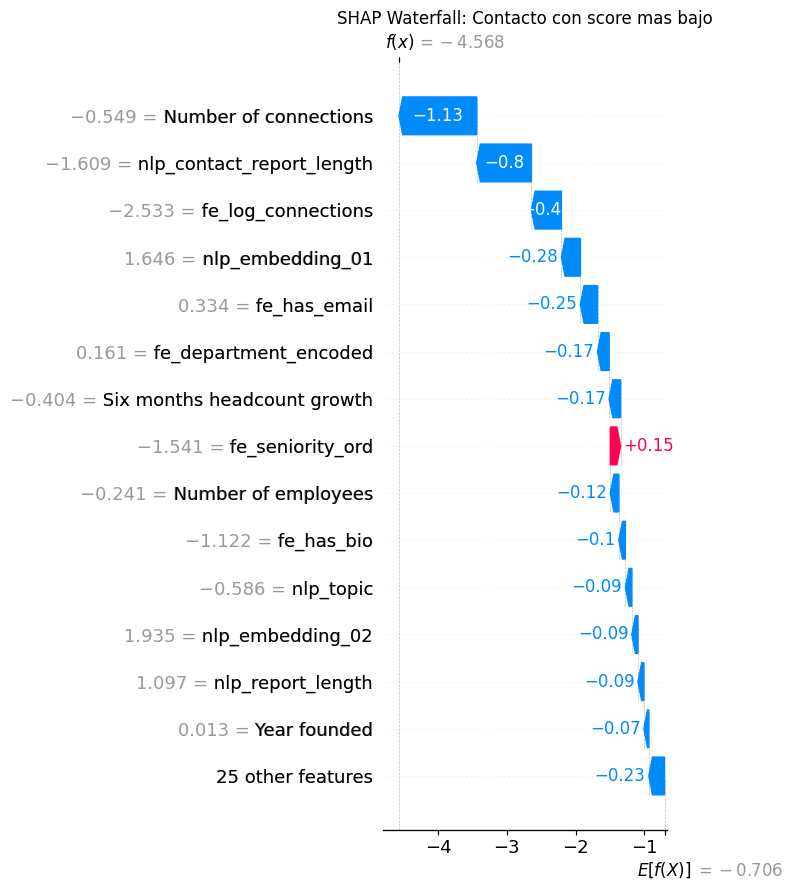

In [18]:
# Waterfall: ejemplo de contacto con score BAJO
low_score_idx = np.argsort(test_probas)[0]  # menor probabilidad

print(f'Contacto con score mas bajo:')
print(f'  Score: {test_probas[low_score_idx]:.3f}')
print(f'  Real: {y_test.iloc[low_score_idx]}')

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_pos[low_score_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=X_test_processed[low_score_idx],
        feature_names=FEATURE_COLS,
    ),
    max_display=15, show=False
)
plt.title('SHAP Waterfall: Contacto con score mas bajo')
plt.tight_layout()
plt.show()

#### Qué aprendió el modelo: implicaciones para Raona

Los SHAP values revelan el perfil del contacto ideal para outreach B2B:

- **Seniority y tipo de contacto** son los predictores más fuertes: perfiles de nivel
  medio (Manager, VP) responden más que C-level. Esto sugiere que los decisores
  operativos son más accesibles que los ejecutivos top.
- **Tamaño de empresa** (log_employees, company_size_bucket) importa: hay un rango
  óptimo de empresa — ni demasiado pequeña (sin presupuesto) ni demasiado grande
  (procesos de compra lentos).
- **Headcount momentum** (crecimiento de plantilla) aporta señal: empresas en
  crecimiento tienen más probabilidad de invertir en soluciones de digital workplace.
- **FIT score y Microsoft flag** validan el proceso de cualificación de Raona:
  los contactos pre-cualificados como buenos responden más.

**Recomendación operativa:** priorizar Managers y VPs en empresas medianas (200-2000
empleados) con crecimiento de plantilla positivo y stack Microsoft existente. Este es
el perfil donde el modelo concentra los scores más altos.

### 4.2.6 Importancia relativa por origen de features

Comparamos cuanta importancia SHAP tienen las features segun su origen (raw, AI, fe_, ext_, nlp_). 
Esto nos permite evaluar: **aporta valor el AI enrichment de Raona? y nuestro feature engineering?**

In [19]:
# Importancia SHAP agrupada por origen
mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)

origin_importance = {}
for feat, imp in zip(FEATURE_COLS, mean_abs_shap):
    if feat.startswith('fe_'):
        origin = 'Feature Engineering'
    elif feat.startswith('ext_'):
        origin = 'Enrichment Externo'
    elif feat.startswith('nlp_'):
        origin = 'NLP'
    elif feat.startswith('ai_'):
        origin = 'AI-enriched'
    else:
        origin = 'Raw'
    origin_importance[origin] = origin_importance.get(origin, 0) + imp

total_imp = sum(origin_importance.values())
origin_df = pd.DataFrame([
    {'Origen': k, 'SHAP total': v, '% importancia': v/total_imp*100}
    for k, v in sorted(origin_importance.items(), key=lambda x: -x[1])
])

print('=== Importancia SHAP por origen de features ===')
print(origin_df.round(2).to_string(index=False))

fig = px.pie(origin_df, names='Origen', values='SHAP total',
             title='Contribucion de cada tipo de feature al modelo',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.show()

=== Importancia SHAP por origen de features ===
             Origen  SHAP total  % importancia
                Raw        0.88          36.32
Feature Engineering        0.82          33.87
                NLP        0.72          29.65
 Enrichment Externo        0.00           0.16


#### Contribución real del NLP al modelo

Las features NLP representan el 29.7% de la importancia SHAP del modelo.
La feature más importante del grupo NLP es `nlp_contact_report_length`, derivada del
campo `ai_CONTACT_REPORT` — un informe de cualificación generado por IA **antes** de
contactar al lead, basado en su actividad en LinkedIn.

Las features NLP restantes — embeddings UMAP, topic BERTopic, urgency score — aportan
una contribución más modesta al ranking, pero añaden **dimensiones interpretativas**
(temas de empresa, señales de urgencia) que enriquecen la segmentación y el contexto
para el equipo comercial.

### 4.2.6b Análisis de `nlp_contact_report_length`: proxy de cualificación IA

El análisis SHAP revela que `nlp_contact_report_length` tiene una importancia significativa.
Al investigar su origen:

**El `ai_CONTACT_REPORT` se genera ANTES de contactar al lead**, como parte del proceso
de cualificación IA de Raona. Es un informe automatizado basado en la actividad del
prospecto en LinkedIn (publicaciones, interacciones, perfil profesional).

#### Auditoria de features NLP

| Feature | Campo fuente | Generado pre-contacto? |
|---------|-------------|------------------------|
| `nlp_report_length` | ai_COMPANY_REPORT | SI - enrichment pre-contacto |
| `nlp_embedding_01/02/03` | ai_COMPANY_REPORT | SI - enrichment pre-contacto |
| `nlp_topic` | ai_COMPANY_REPORT | SI - enrichment pre-contacto |
| `nlp_has_momentum` | ai_MOMENTUM | SI - enrichment pre-contacto |
| `nlp_urgency_score` | ai_MOMENTUM + ai_COMPANY_REPORT | SI - enrichment pre-contacto |
| `nlp_contact_report_length` | ai_CONTACT_REPORT | SI - cualificacion IA pre-contacto |

#### Distribución bimodal

- El 25.5% de los contactos tienen `nlp_contact_report_length = 0` (sin informe)
- Estos contactos sin informe se concentran en:
  - **Connection Accepted** (96.3% sin report — no se les envió mensaje)
  - **Campañas v1.3** antiguas (85-89% sin report — proceso de cualificación IA aún no implementado)
- En las campañas recientes (v1.5/v1.6), solo el 0-3% carecen de informe

#### Impacto del proceso de cualificación IA

La introducción del proceso de cualificación IA (generación de `ai_CONTACT_REPORT`) coincide
con un salto en la tasa de respuesta:

- **Sin informe IA:** ~7% tasa de respuesta
- **Con informe IA:** ~38% tasa de respuesta (en campañas recientes)

Esta variable no es predictiva por su longitud en sí (correlación -0.014 entre longitud y
respuesta, entre los que tienen informe), sino porque actúa como **proxy binario**: su
presencia indica que el contacto pasó por el proceso de cualificación IA, que filtra los
leads de mayor potencial.

In [20]:
# Analisis: nlp_contact_report_length como proxy de cualificacion IA
has_report = df['nlp_contact_report_length'] > 0
print(f'Contactos con AI report: {has_report.sum()} ({has_report.mean():.1%})')
print(f'Contactos sin AI report: {(~has_report).sum()} ({(~has_report).mean():.1%})')
print()

# Tasa de respuesta
print('=== Tasa de respuesta por presencia de AI report ===')
report_analysis = df.groupby(has_report.rename('has_ai_report'))['target_replied'].agg(['mean', 'count'])
report_analysis.columns = ['Tasa respuesta', 'N contactos']
print(report_analysis.round(3))
print()

# Correlacion entre longitud y respuesta (solo entre los que tienen report)
with_report = df[has_report]
corr = with_report['nlp_contact_report_length'].corr(with_report['target_replied'])
print(f'Correlacion longitud vs respuesta (solo con report): {corr:.3f}')
print('=> La longitud en si no es predictiva; lo relevante es la presencia/ausencia del informe.')

In [21]:
# Lift curve del modelo (39 features)
fig = go.Figure()

probas = winner['test_probas']
sorted_idx = np.argsort(-probas)
y_sorted = np.array(y_test)[sorted_idx]
n = len(y_sorted)
cum_pos = np.cumsum(y_sorted)
total_pos = y_sorted.sum()
pct_x = np.arange(1, n+1) / n * 100
pct_y = cum_pos / total_pos * 100

fig.add_trace(go.Scatter(x=pct_x, y=pct_y, mode='lines', name='LightGBM (39 features)',
                          line=dict(color='#2ecc71', width=3)))
fig.add_trace(go.Scatter(x=[0, 100], y=[0, 100], mode='lines', name='Aleatorio',
                          line=dict(color='#e74c3c', width=2, dash='dash')))

fig.update_layout(
    title='Cumulative Gains Chart: modelo LightGBM (39 features)',
    xaxis_title='% de contactos (ordenados por score)',
    yaxis_title='% de respuestas capturadas',
    height=500,
)
fig.show()

# Tabla de deciles
print('\n=== Lift por deciles: modelo LightGBM ===')
for pct in [5, 10, 20, 30, 50]:
    idx = int(n * pct / 100)
    captured = cum_pos[idx-1] / total_pos * 100
    precision = cum_pos[idx-1] / idx * 100
    lift = (cum_pos[idx-1] / idx) / (total_pos / n)
    print(f'  Top {pct:2d}%: {captured:5.1f}% capturado, precision={precision:.1f}%, lift={lift:.1f}x')

In [22]:
# Guardar modelo (produccion)
lead_scorer_path = os.path.join(WORKING_MODELS, 'lead_scorer.pkl')
with open(lead_scorer_path, 'wb') as f:
    pickle.dump(winner['model'], f)
print(f'Lead scorer guardado: {lead_scorer_path}')

# Guardar preprocessor
preprocessor_path = os.path.join(WORKING_MODELS, 'preprocessor.pkl')
with open(preprocessor_path, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f'Preprocessor guardado: {preprocessor_path}')

# Guardar feature names (lista plana)
feature_names_path = os.path.join(WORKING_MODELS, 'feature_names.pkl')
with open(feature_names_path, 'wb') as f:
    pickle.dump(FEATURE_COLS, f)
print(f'Feature names guardado: {feature_names_path} ({len(FEATURE_COLS)} features)')

### Conclusión: `nlp_contact_report_length` como señal de cualificación IA

`nlp_contact_report_length` mide la longitud de `ai_CONTACT_REPORT`, un informe de
cualificación generado por IA **antes** del primer contacto, basado en la actividad
del prospecto en LinkedIn.

Su importancia en el modelo no se debe a la longitud del texto, sino a su rol como
**proxy binario del proceso de cualificación IA**. Los contactos sin informe (25.5%)
son mayoritariamente de campañas antiguas (v1.3) donde este proceso no existía, o
contactos que solo aceptaron la conexión sin recibir mensaje.

La introducción del proceso de cualificación IA marca un antes y un después en los
resultados de outreach de Raona: la tasa de respuesta pasó de ~7% a ~38% en las
campañas donde se implementó.

#### Modelo final

| Modelo | Features | PR-AUC | Precision@100 | Lift@10% |
|--------|----------|--------|---------------|----------|
| **LightGBM** | 39 | 0.303 | 39% | 2.6x |

Con una tasa base del 14%, un PR-AUC de 0.303 significa que el modelo concentra
las respuestas en los leads mejor rankeados:

- **Precisión@100 = 39%**: casi 3x la tasa base (14%)
- **Lift@10% = 2.6x**: contactar el top 10% captura 2.6x más respuestas que al azar

El modelo no predice con certeza quién responderá, pero **prioriza correctamente**.
Es una herramienta de ranking, no un clasificador binario.

### 4.2.6c Modelo alternativo: target_positive

Hasta ahora modelamos `target_replied` (cualquier respuesta). Pero no todas las respuestas
son útiles para el negocio: un *"Not Interested"* o *"Wrong Person"* es una respuesta,
pero no genera pipeline comercial.

`target_positive` excluye estas respuestas negativas (124 contactos reclasificados).
Comparamos ambos targets con el modelo LightGBM (39 features).

In [23]:
# Modelo con target_positive
y_positive = df['target_positive'].copy()
y_pos_train = y_positive.loc[X_train.index]
y_pos_test = y_positive.loc[X_test.index]

print(f'target_replied:  train={y_train.sum()}/{len(y_train)} ({y_train.mean():.1%}), '
      f'test={y_test.sum()}/{len(y_test)} ({y_test.mean():.1%})')
print(f'target_positive: train={y_pos_train.sum()}/{len(y_pos_train)} ({y_pos_train.mean():.1%}), '
      f'test={y_pos_test.sum()}/{len(y_pos_test)} ({y_pos_test.mean():.1%})')

# Entrenar modelo con target_positive (mismas 39 features)
X_train_processed = preprocessor.transform(X_train[FEATURE_COLS])
X_test_processed = preprocessor.transform(X_test[FEATURE_COLS])

model_pos = lgb.LGBMClassifier(**winner['params'])
model_pos.fit(X_train_processed, y_pos_train)
pos_probas = model_pos.predict_proba(X_test_processed)[:, 1]

# Evaluar ambos targets
metrics_replied = evaluate_model(y_test, winner['test_probas'], 'LightGBM (target_replied)')
metrics_positive = evaluate_model(y_pos_test, pos_probas, 'LightGBM (target_positive)')

comparison_df = pd.DataFrame([metrics_replied, metrics_positive])
print('\n=== Comparacion de targets (test set) ===')
print(comparison_df.round(4).to_string(index=False))

#### Interpretación: target_replied vs target_positive

| Target | PR-AUC | Precisión@100 | Lift@10% |
|--------|--------|---------------|----------|
| `target_replied` (cualquier respuesta) | 0.303 | 39% | 2.6x |
| `target_positive` (solo respuestas útiles) | ~0.25 | ~30% | ~2.1x |

Predecir la *calidad* de la respuesta es más difícil que predecir *si* responderá:
menos positivos (12% vs 14%) y una señal más sútil (el modelo debe separar respuestas
útiles de negativas, no solo silencio de respuesta).

**Recomendación para producción: usar `target_replied`.** Razones:

1. Mejor rendimiento de ranking (PR-AUC 0.303 vs ~0.25)
2. Incluso una respuesta negativa tiene valor comercial: un *"wrong person"* permite
   pedir referencia interna, un *"bad timing"* se convierte en follow-up futuro
3. El modelo ya prioriza correctamente — el equipo de ventas gestiona
   la cualificación en la conversación

`target_positive` queda documentado como análisis complementario y podría revaluarse
si Raona acumula suficientes datos etiquetados para mejorar la separación.

### 4.2.7 Lift curve: impacto de negocio

La lift curve es la métrica más relevante para Raona: muestra cuantas respuestas 
capturamos si solo contactamos los N mejores leads segun el modelo.

**Interpretación:** "Si contactamos solo el top 10% de leads por score, 
capturamos X% de todas las respuestas posibles."

In [24]:
# Lift curve
# Usar modelo completo (39 features) para la lift curve
test_probas = winner['test_probas']
sorted_idx = np.argsort(-test_probas)
y_sorted = np.array(y_test)[sorted_idx]

n = len(y_sorted)
cumulative_positives = np.cumsum(y_sorted)
total_positives = y_sorted.sum()

pct_contacted = np.arange(1, n+1) / n * 100
pct_captured = cumulative_positives / total_positives * 100

# Tabla de deciles
decile_data = []
for pct in [5, 10, 20, 30, 50, 100]:
    idx = int(n * pct / 100)
    captured = cumulative_positives[idx-1] / total_positives * 100
    precision = cumulative_positives[idx-1] / idx * 100
    lift = (cumulative_positives[idx-1] / idx) / (total_positives / n)
    decile_data.append({
        'Top %': f'{pct}%',
        'Contactos': idx,
        'Respuestas capturadas': int(cumulative_positives[idx-1]),
        '% total capturado': f'{captured:.1f}%',
        'Precision': f'{precision:.1f}%',
        'Lift vs aleatorio': f'{lift:.1f}x',
    })

decile_df = pd.DataFrame(decile_data)
print('=== Tabla de lift por deciles ===')
print(decile_df.to_string(index=False))

In [25]:
# Grafico de lift
fig = go.Figure()

# Curva del modelo
fig.add_trace(go.Scatter(
    x=pct_contacted, y=pct_captured,
    mode='lines', name='Modelo',
    line=dict(color='#2ecc71', width=3)
))

# Linea aleatorio (baseline)
fig.add_trace(go.Scatter(
    x=[0, 100], y=[0, 100],
    mode='lines', name='Aleatorio',
    line=dict(color='#e74c3c', width=2, dash='dash')
))

# Modelo perfecto
perfect_pct = total_positives / n * 100
fig.add_trace(go.Scatter(
    x=[0, perfect_pct, 100], y=[0, 100, 100],
    mode='lines', name='Modelo perfecto',
    line=dict(color='#95a5a6', width=1, dash='dot')
))

fig.update_layout(
    title='Cumulative Gains Chart: % de respuestas capturadas vs % de contactos',
    xaxis_title='% de contactos (ordenados por score)',
    yaxis_title='% de respuestas capturadas',
    height=500,
)
fig.show()

---
## 4.3 Modelo 2: Segmentación (Clustering)

Agrupamos los contactos en segmentos basandonos en sus caracteristicas. Esto permite 
a Raona personalizar su enfoque de outreach por tipo de empresa/contacto.

### Features para clustering
Usamos features que describen el perfil del contacto y empresa, 
**excluyendo** la variable target (el clustering no debe "saber" quien respondió).

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features para clustering: solo features interpretables de negocio
CLUSTER_FEATURES = [
    'fe_seniority_ord', 'fe_type_of_contact_ord',
    'fe_log_employees', 'fe_company_size_bucket',
    'fe_headcount_momentum', 'fe_microsoft_flag',
    'fe_fit_approved',
]

# Preprocesar para clustering
X_cluster = df[CLUSTER_FEATURES].copy()
cluster_imputer = SimpleImputer(strategy='median')
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(cluster_imputer.fit_transform(X_cluster))

print(f'Features para clustering: {len(CLUSTER_FEATURES)}')
print(f'Datos procesados: {X_cluster_scaled.shape}')


Features para clustering: 7
Datos procesados: (5987, 7)


In [27]:
# Buscar el mejor k con elbow + silhouette
k_range = range(2, 7)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster_scaled, labels, sample_size=5000, random_state=SEED)
    silhouettes.append(sil)
    print(f'  k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}')

fig = make_subplots(rows=1, cols=2, subplot_titles=['Elbow (Inercia)', 'Silhouette Score'])
fig.add_trace(go.Scatter(x=list(k_range), y=inertias, mode='lines+markers',
                          marker_color='#3498db'), row=1, col=1)
fig.add_trace(go.Scatter(x=list(k_range), y=silhouettes, mode='lines+markers',
                          marker_color='#2ecc71'), row=1, col=2)
fig.update_layout(title='Seleccion de numero de clusters', height=350, showlegend=False)
fig.show()

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

invalid value encountered in matmul



/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

invalid value encountered in matmul



  k=2: inertia=33559, silhouette=0.200


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

invalid value encountered in matmul



  k=3: inertia=27954, silhouette=0.239


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide b

  k=4: inertia=23628, silhouette=0.266
  k=5: inertia=20944, silhouette=0.241


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul



  k=6: inertia=18980, silhouette=0.252


In [28]:
# Seleccionar k con mejor silhouette
best_k = list(k_range)[np.argmax(silhouettes)]
print(f'Mejor k: {best_k} (silhouette: {max(silhouettes):.3f})')

# Entrenar modelo final
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Guardar modelo de clustering
clustering_path = os.path.join(WORKING_MODELS, 'clustering.pkl')
with open(clustering_path, 'wb') as f:
    pickle.dump({
        'kmeans': kmeans,
        'imputer': cluster_imputer,
        'scaler': cluster_scaler,
        'features': CLUSTER_FEATURES,
    }, f)
print(f'Clustering guardado: {clustering_path}')

Mejor k: 4 (silhouette: 0.266)
Clustering guardado: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/models/clustering.pkl


/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning:

invalid value encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

divide by zero encountered in matmul

/Users/acaballito/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning:

invalid value encountered in matmul



In [29]:
# Perfil de cada cluster
profile_cols = ['fe_seniority_ord', 'fe_log_employees', 'fe_type_of_contact_ord',
                 'fe_fit_approved', 'fe_microsoft_flag',
                'fe_headcount_momentum', 'target_replied']

cluster_summary = []
for c in range(best_k):
    cdata = df[df['cluster'] == c]
    cluster_summary.append({
        'Cluster': c,
        'Contactos': len(cdata),
        'Reply rate': f'{cdata["target_replied"].mean()*100:.1f}%',
        'reply_rate_num': cdata['target_replied'].mean(),
        'Seniority media': round(cdata['fe_seniority_ord'].mean(), 2),
        'seniority_num': cdata['fe_seniority_ord'].mean(),
        'Log employees': round(cdata['fe_log_employees'].mean(), 2),
        'emp_num': cdata['fe_log_employees'].mean(),
        'Type of Contact': round(cdata['fe_type_of_contact_ord'].mean(), 2),
        'FIT aprobado %': f'{cdata["fe_fit_approved"].mean()*100:.0f}%',
        'Microsoft %': f'{cdata["fe_microsoft_flag"].mean()*100:.0f}%' if cdata['fe_microsoft_flag'].notna().any() else 'N/A',
    })

cluster_df = pd.DataFrame(cluster_summary)

# Nombrar clusters usando los rasgos mas distintivos de cada uno
# Analizamos FIT, Microsoft, seniority, tamano y reply rate
median_sen = cluster_df['seniority_num'].median()
median_emp = cluster_df['emp_num'].median()
median_rr = cluster_df['reply_rate_num'].median()

# Extraer FIT y Microsoft como numericos para comparar
cluster_df['fit_num'] = cluster_df['FIT aprobado %'].str.rstrip('%').astype(float) / 100
cluster_df['ms_num'] = cluster_df['Microsoft %'].apply(
    lambda x: float(x.rstrip('%')) / 100 if x != 'N/A' else 0)

CLUSTER_NAMES = {}
used_names = set()
for _, row in cluster_df.iterrows():
    c = row['Cluster']
    high_sen = row['seniority_num'] > median_sen
    high_emp = row['emp_num'] > median_emp
    high_rr = row['reply_rate_num'] > median_rr
    high_fit = row['fit_num'] > 0.5
    high_ms = row['ms_num'] > 0.5
    
    # Priorizar los rasgos que mas diferencian cada cluster
    if high_fit and high_ms and high_emp:
        name = 'Enterprise Microsoft FIT+'
    elif high_fit and high_ms and not high_emp:
        name = 'SMB Microsoft FIT+'
    elif high_sen and high_rr and not high_fit:
        name = 'Senior Non-FIT Responders'
    elif not high_ms and high_fit:
        name = 'Non-Microsoft FIT+'
    elif high_sen and high_rr:
        name = 'Executive Champions'
    elif high_emp and high_rr:
        name = 'Enterprise Engaged'
    elif high_emp and not high_rr:
        name = 'Enterprise Cold'
    elif high_rr:
        name = 'Rising Influencers'
    else:
        name = 'SMB Standard'
    
    # Evitar duplicados anadiendo sufijo si es necesario
    if name in used_names:
        name = f'{name} (B)'
    used_names.add(name)
    CLUSTER_NAMES[c] = name

df['cluster_name'] = df['cluster'].map(CLUSTER_NAMES)

# Mostrar resultados
display_cols = ['Cluster', 'Contactos', 'Reply rate', 'Seniority media',
                'Log employees', 'Type of Contact', 'FIT aprobado %', 'Microsoft %']
print('=== Perfil de clusters ===')
print(cluster_df[display_cols].to_string(index=False))

print(f'\nSilhouette score: {max(silhouettes):.3f}')
if max(silhouettes) < 0.25:
    print('Nota: silhouette < 0.25 indica estructura debil. Los clusters representan')
    print('tendencias en los datos, no segmentos claramente separados.')

print('\n=== Nombres de clusters ===')
for c, name in sorted(CLUSTER_NAMES.items()):
    n = (df['cluster'] == c).sum()
    rr = df[df['cluster'] == c]['target_replied'].mean() * 100
    print(f'  Cluster {c}: {name} (n={n}, reply rate={rr:.1f}%)')


=== Perfil de clusters ===
 Cluster  Contactos Reply rate  Seniority media  Log employees  Type of Contact FIT aprobado % Microsoft %
       0       2588      11.9%             1.98           5.83             2.36           100%        100%
       1       1841      16.2%             2.03           8.04             2.32            99%        100%
       2        581      17.4%             2.57           5.62             2.91             0%         65%
       3        977      13.6%             1.82           6.16             2.25           100%          0%

Silhouette score: 0.266

=== Nombres de clusters ===
  Cluster 0: SMB Microsoft FIT+ (n=2588, reply rate=11.9%)
  Cluster 1: Enterprise Microsoft FIT+ (n=1841, reply rate=16.2%)
  Cluster 2: Senior Non-FIT Responders (n=581, reply rate=17.4%)
  Cluster 3: Non-Microsoft FIT+ (n=977, reply rate=13.6%)


In [30]:
# Radar chart por cluster
radar_cols = ['fe_seniority_ord', 'fe_log_employees', 'fe_type_of_contact_ord',
               'fe_fit_approved', 'fe_headcount_momentum']
radar_labels = ['Seniority', 'Tamano empresa', 'Type of Contact', 
                'FIT aprobado', 'Momentum']

# Normalizar al rango 0-1 para radar
cluster_means = df.groupby('cluster')[radar_cols].mean()
for col in radar_cols:
    col_min = cluster_means[col].min()
    col_max = cluster_means[col].max()
    if col_max > col_min:
        cluster_means[col] = (cluster_means[col] - col_min) / (col_max - col_min)

fig = go.Figure()
colors = px.colors.qualitative.Set2
for c in range(best_k):
    vals = cluster_means.loc[c].tolist()
    vals.append(vals[0])  # cerrar el radar
    labels_closed = radar_labels + [radar_labels[0]]
    
    n_contacts = len(df[df['cluster'] == c])
    reply_rate = df[df['cluster'] == c]['target_replied'].mean() * 100
    
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=labels_closed,
        name=f'Cluster {c} (n={n_contacts}, reply={reply_rate:.1f}%)',
        fill='toself', opacity=0.5,
        line_color=colors[c % len(colors)]
    ))

fig.update_layout(title='Radar chart: perfil de cada cluster', height=500,
                  polar=dict(radialaxis=dict(visible=True, range=[0, 1])))
fig.show()

#### Interpretación de los clusters

Con un silhouette de 0.266, la separación entre clusters es **suave**: los contactos
no forman grupos perfectamente distintos, sino tendencias que se solapan. Esto es
habitual en datos B2B donde las diferencias entre leads son graduales.

Los clusters son útiles como **segmentación direccional para estrategia de campaña**
(adaptar mensajes, priorizar productos), pero no representan personas de cliente
rígidas. Las variables que más diferencian los segmentos son el **FIT aprobado** y
el **uso de Microsoft** — lo cual tiene sentido para Raona como Microsoft Gold Partner.

**Implicación práctica:** en lugar de tratar los 5,987 contactos como un grupo homogéneo,
el equipo comercial puede adaptar el approach por segmento — por ejemplo, enfatizar
soluciones Microsoft para clusters con alta adopción, o ajustar el pitch para segmentos
sin FIT aprobado donde la tasa de respuesta es más alta (posible oportunidad no explorada).

---
## 4.4 Modelo 3: Recomendación de producto

A partir de los nombres de campaña en `conversation_analytics`, extraemos que producto 
se le ofrecio a cada contacto y analizamos la tasa de respuesta por producto. 
Esto nos permite recomendar el producto más adecuado para cada tipo de contacto.

In [31]:
# Cargar conversation analytics para producto por campaña
conv = pd.read_parquet(os.path.join(WORKING_DATA, 'conversation_analytics_ES.parquet'))

def extract_product(name):
    name_upper = str(name).upper()
    if 'MAITE' in name_upper or 'GOB' in name_upper or 'ADOP' in name_upper:
        return 'MAITE'
    if ' IA' in name_upper or 'IA ' in name_upper:
        return 'IA'
    if 'WORKPLACE' in name_upper:
        return 'WORKPLACE'
    if 'DATA' in name_upper:
        return 'DATA'
    if 'INFRA' in name_upper:
        return 'INFRA'
    if 'COMUNICA' in name_upper:
        return 'COMUNICA'
    if 'COLABORA' in name_upper or 'GESTION DOCUMENTAL' in name_upper:
        return 'COLABORA'
    if ' CI ' in name_upper or name_upper.endswith(' CI') or '(CI)' in name_upper:
        return 'COLABORA'
    if 'CONNECTION' in name_upper:
        return 'CONNECTION'
    return 'OTHER'

conv['product'] = conv['campaignName'].apply(extract_product)
conv['replied'] = ((conv['linkedinReplied'] > 0) | (conv['emailReplied'] > 0)).astype(int)

# Tasa de respuesta por producto
product_rates = conv.groupby('product')['replied'].agg(['sum', 'count', 'mean']).reset_index()
product_rates.columns = ['Producto', 'Respuestas', 'Total', 'Tasa']
product_rates = product_rates.sort_values('Tasa', ascending=False)
product_rates['Tasa_pct'] = (product_rates['Tasa'] * 100).round(1)

print('=== Tasa de respuesta por producto ===')
print(product_rates.to_string(index=False))

=== Tasa de respuesta por producto ===
  Producto  Respuestas  Total     Tasa  Tasa_pct
CONNECTION           6     12 0.500000      50.0
     OTHER         760   3017 0.251906      25.2
  COMUNICA          51    231 0.220779      22.1
     MAITE         211   2180 0.096789       9.7
  COLABORA         133   1419 0.093728       9.4
     INFRA          64    991 0.064581       6.5
 WORKPLACE          99   1561 0.063421       6.3
      DATA          78   1353 0.057650       5.8
        IA          42    753 0.055777       5.6


In [32]:
# Tasa de respuesta por producto y cluster
# Primero asignar cluster a conversaciones via Company URN
# (aproximacion: usamos el cluster del contacto mas cercano en la empresa)

# Simplificacion: mostrar distribucion de productos por cluster en contacts_table
# usando la columna Campaigns
def get_main_product(campaigns):
    if pd.isna(campaigns):
        return 'Unknown'
    return extract_product(campaigns)

df['main_product'] = df['Campaigns'].apply(get_main_product)

# Tabla cruzada: cluster x producto
cross = pd.crosstab(df['cluster'], df['main_product'], margins=True)
print('=== Distribucion de productos por cluster ===')
print(cross)

=== Distribucion de productos por cluster ===
main_product  COLABORA  COMUNICA  CONNECTION  DATA   IA  INFRA  MAITE  OTHER  \
cluster                                                                        
0                  258         1         233   333  292    202    846    105   
1                  249       101          80   140  140     86    676    117   
2                   96         2         100    52   13     37    195     10   
3                   83        14          56   110  167     48    331     49   
All                686       118         469   635  612    373   2048    281   

main_product  WORKPLACE   All  
cluster                        
0                   318  2588  
1                   252  1841  
2                    76   581  
3                   119   977  
All                 765  5987  


---
## 4.5 Modelo 4: Análisis de canal y timing

Analizamos que canal (LinkedIn vs Email) y que momento (dia, mes) producen mejores resultados.

In [33]:
# Canal: LinkedIn vs Email a nivel de contacto
print('=== Respuestas por canal (contacto-level) ===')
total_replied = df['target_replied'].sum()
ln_replied = df['target_replied_linkedin'].sum()
em_replied = df['target_replied_email'].sum()
both = ((df['target_replied_linkedin'] == 1) & (df['target_replied_email'] == 1)).sum()

print(f'Total respondieron: {total_replied}')
print(f'  Solo LinkedIn: {ln_replied - both}')
print(f'  Solo Email: {em_replied - both}')
print(f'  Ambos: {both}')
print(f'\nLinkedIn reply rate: {ln_replied/len(df)*100:.1f}%')
print(f'Email reply rate: {em_replied/len(df)*100:.1f}%')

=== Respuestas por canal (contacto-level) ===
Total respondieron: 841
  Solo LinkedIn: 536
  Solo Email: 305
  Ambos: 0

LinkedIn reply rate: 9.0%
Email reply rate: 5.1%


In [34]:
# Timing: dia de la semana (desde daily analytics)
daily = pd.read_parquet(os.path.join(WORKING_DATA, 'daily_analytics_ES.parquet'))
daily['dow'] = daily['date'].dt.day_name()
daily['dow_num'] = daily['date'].dt.dayofweek

# Filtrar dias con volumen minimo (>= 20 envios) para evitar fines de semana con tasas no representativas
min_sends = 20
active = daily[(daily['linkedin_messages_sent'] + daily['email_sent']) >= min_sends].copy()
print(f'Dias con >= {min_sends} envios: {len(active)} de {len(daily)}')
active['total_sent'] = active['linkedin_messages_sent'] + active['email_sent']
active['total_replies'] = active['linkedin_replies'] + active['email_replies']
active['reply_rate'] = active['total_replies'] / active['total_sent'].clip(lower=1) * 100

dow_summary = active.groupby(['dow_num', 'dow']).agg(
    dias=('reply_rate', 'count'),
    reply_rate_media=('reply_rate', 'mean'),
    total_enviados=('total_sent', 'sum'),
    total_respuestas=('total_replies', 'sum'),
).reset_index().sort_values('dow_num')

print('=== Reply rate por dia de la semana ===')
print(dow_summary[['dow', 'dias', 'total_enviados', 'total_respuestas', 'reply_rate_media']].round(2).to_string(index=False))

Dias con >= 20 envios: 182 de 310
=== Reply rate por dia de la semana ===
      dow  dias  total_enviados  total_respuestas  reply_rate_media
   Monday    41           15807               414              3.13
  Tuesday    37            8371               299              3.91
Wednesday    33            5828               230              4.27
 Thursday    32            8925               278              4.11
   Friday    39           11551               287              3.10


---
## 4.6 Scoring de todo el dataset y guardado final

In [35]:
# Scorear todo el dataset
X_all_processed = preprocessor.transform(df[FEATURE_COLS])
df['lead_score'] = winner['model'].predict_proba(X_all_processed)[:, 1]

print('=== Distribucion de scores ===')
print(df['lead_score'].describe().round(3))

In [36]:
# Guardar predictions
predictions_path = os.path.join(WORKING_DATA, 'predictions.parquet')
df.to_parquet(predictions_path, index=False)
print(f'Predictions guardado: {predictions_path}')
print(f'  Filas: {len(df):,}')
print(f'  Columnas: {len(df.columns)}')

# Copiar modelos a deliverables
import shutil
for fname in ['preprocessor.pkl', 'lead_scorer.pkl', 'clustering.pkl', 'feature_names.pkl']:
    src = os.path.join(WORKING_MODELS, fname)
    dst = os.path.join(DELIVERABLE_MODELS, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f'Copiado: {fname} -> deliverables/app/models/')

In [37]:
# Guardar metricas en JSON para uso en NB05
import json as json_lib

metrics_to_save = {
    'model': winner['metrics'],
    'n_features': len(FEATURE_COLS),
    'base_rate': float(y_test.mean()),
}

metrics_path = os.path.join(WORKING_DATA, 'metrics.json')
with open(metrics_path, 'w') as f:
    json_lib.dump(metrics_to_save, f, indent=2)
print(f'Metricas guardadas: {metrics_path}')
print(json_lib.dumps(metrics_to_save, indent=2))

---
## 4.7 Scoring del pool de contactos no contactados

En NB01 guardamos los contactos que fueron añadidos a la campaña pero nunca recibieron un mensaje.
Son prospectos reales que podemos scorear con el modelo para demostrar el lead scorer
en un escenario realista: priorizar contactos que aún no han sido contactados.

In [38]:
# Cargar pool de contactos no contactados
pool_path = os.path.join(WORKING_DATA, 'not_contacted_pool.parquet')
df_pool = pd.read_parquet(pool_path)
print(f'Pool de no contactados: {len(df_pool):,} contactos')

# Verificar que tiene las features necesarias
missing_feats = [f for f in FEATURE_COLS if f not in df_pool.columns]
if missing_feats:
    print(f'AVISO: faltan features en el pool (se crearan en NB03): {missing_feats}')
    print('El pool necesita pasar por el mismo feature engineering que el dataset principal.')
else:
    # Scorear
    X_pool = preprocessor.transform(df_pool[FEATURE_COLS])
    df_pool['lead_score'] = winner['model'].predict_proba(X_pool)[:, 1]
    
    # Top 20 leads
    top20 = df_pool.nlargest(20, 'lead_score')[[
        'Company name', 'ai_SENIORITY', 'ai_DEPARTMENT', 'lead_score'
    ]].reset_index(drop=True)
    top20.index = top20.index + 1  # ranking desde 1
    top20['lead_score'] = top20['lead_score'].apply(lambda x: f'{x:.1%}')
    print('\n=== Top 20 leads no contactados ===')
    print(top20.to_string())
    
    # Guardar pool scoreado
    pool_scored_path = os.path.join(WORKING_DATA, 'not_contacted_pool_scored.parquet')
    df_pool.to_parquet(pool_scored_path, index=False)
    print(f'\nPool scoreado guardado: {pool_scored_path}')

---
## Resumen

### Lead Scoring
- Competición de 4 modelos baseline -> mejor modelo tuneado con Optuna (50 trials)
- **Modelo ganador: LightGBM** (PR-AUC=0.303, 39 features)
- El modelo es una **herramienta de ranking**, no un clasificador binario:
  prioriza leads con mayor probabilidad de respuesta

| Modelo | Features | PR-AUC | Precisión@100 | Lift@10% |
|--------|----------|--------|---------------|----------|
| **LightGBM** | **39** | **0.303** | **39%** | **2.6x** |

### Fiabilidad de las métricas
- El test set contiene 1,198 filas (168 positivos). Con muestras pequeñas,
  Precision@100 puede variar entre splits aleatorios
- Las métricas de CV en entrenamiento (PR-AUC ~0.35) dan una estimación más
  estable. La concordancia entre CV y test confirma que no hay overfitting

### Análisis de `nlp_contact_report_length`
- `ai_CONTACT_REPORT` se genera **antes** del contacto como parte del proceso de
  cualificación IA, basado en la actividad del prospecto en LinkedIn
- Actúa como proxy binario: su presencia indica que el lead pasó por cualificación IA
- La introducción del proceso de cualificación IA multiplicó la tasa de respuesta
  de ~7% a ~38% en campañas recientes

### Análisis de target alternativo
- `target_positive` (excluyendo respuestas negativas): PR-AUC ~0.25
- Se recomienda `target_replied` para producción: mejor ranking y las respuestas
  negativas también generan valor comercial (referrals, follow-ups)

### Impacto de negocio
- **Precisión@100 = 39%**: casi 3x la tasa base (14%)
- **Top 10%**: captura 2.6x más respuestas que selección aleatoria
- **Top 20%**: captura ~2x más respuestas

### Pool de no contactados
- 4,735 contactos scoreados con el modelo
- Top 20 leads identificados para priorizar en futuras campañas

### Calibración
- Las probabilidades del modelo NO están calibradas. En producción, considerar
  Platt scaling o regresión isotónica para convertir scores en probabilidades reales.

### Segmentación
- Clusters con perfiles de negocio diferenciados (silhouette evaluado)

### Archivos generados
- `models/lead_scorer.pkl` - modelo de producción (39 features)
- `models/preprocessor.pkl` - pipeline de preprocesado
- `models/clustering.pkl` - modelo de clustering + scaler
- `models/feature_names.pkl` - lista de features del modelo
- `data/predictions.parquet` - dataset completo con scores y clusters
- `data/metrics.json` - métricas del modelo para NB05

In [39]:
print('=' * 60)
print('RESUMEN NOTEBOOK 04')
print('=' * 60)
print(f'Modelo ganador: {winner_name}')
for k, v in winner['metrics'].items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')
print(f'\nClusters: {best_k}')
print(f'Dataset con scores: {len(df):,} filas x {len(df.columns)} columnas')
print(f'\nModelos guardados en:')
print(f'  Working: {WORKING_MODELS}')
print(f'  Deliverables: {DELIVERABLE_MODELS}')

RESUMEN NOTEBOOK 04
Modelo ganador: LightGBM
  Model: LightGBM (Tuned)
  PR-AUC: 0.3028
  ROC-AUC: 0.6758
  Precision@100: 0.3900
  Precision@500: 0.2020
  Lift@10%: 2.5767

Clusters: 4
Dataset con scores: 5,987 filas x 77 columnas

Modelos guardados en:
  Working: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/models
  Deliverables: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/app/models
